# Distribution shift, threshold tradeoffs, and a nonlinear model

In this notebook, we train on the existing 20-item instances, compare the untouched 20-item test split with fresh 40-item instances, sweep the routing threshold, and only then train a random forest as a nonlinear comparison.

In [1]:
import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from knapsack_ml_experiment import (
    FEATURE_COLUMNS,
    Item,
    build_labeled_dataset,
    extract_hybrid_features,
    generate_independent_instances,
    generate_similar_ratio_instances,
    generate_strongly_correlated_instances,
    generate_weakly_correlated_instances,
    split_dataset_by_seed,
)

## Recreate the leakage-safe training and test data

The classifier inputs contain only information available before solving the instance. Dynamic-programming outputs such as `optimal_value`, `relative_gap`, and `failure` are retained only for evaluation. Splitting by seed keeps related rows from different families together.

In [2]:
independent = pd.read_csv("../artifacts/independent_instances.csv")
other_families = pd.read_csv("../artifacts/other_family_instances.csv")
dataset = pd.concat([independent, other_families], ignore_index=True)
dataset["weights"] = dataset["weights"].apply(ast.literal_eval)
dataset["values"] = dataset["values"].apply(ast.literal_eval)


def items_from_row(row):
    return [
        Item(f"item_{index}", weight, value)
        for index, (weight, value) in enumerate(zip(row.weights, row.values))
    ]


def add_features(frame):
    result = frame.copy().reset_index(drop=True)
    feature_rows = [
        extract_hybrid_features(items_from_row(row), row.capacity).iloc[0].to_dict()
        for row in result.itertuples(index=False)
    ]
    features = pd.DataFrame(feature_rows, columns=FEATURE_COLUMNS)
    for column in FEATURE_COLUMNS:
        result[column] = features[column]
    return result


model_data = add_features(dataset)
train, validation, in_distribution_test = split_dataset_by_seed(
    model_data, random_seed=0
)

{
    "training_rows": len(train),
    "validation_rows": len(validation),
    "in_distribution_test_rows": len(in_distribution_test),
}

{'training_rows': 2800,
 'validation_rows': 600,
 'in_distribution_test_rows': 600}

## Create a larger-instance test set

The training data always has 20 items. The out-of-distribution (OOD) set instead has 40 items, while retaining the same four generator families and default weight, value, and capacity settings. Fresh seeds beginning at 10,000 prevent overlap with the saved data. This is a controlled **size shift**: any change in behavior should not be attributed to a new family at the same time.

In [3]:
OOD_INSTANCES_PER_FAMILY = 250
OOD_NUMBER_OF_ITEMS = 40
OOD_STARTING_SEED = 10_000

ood_instances = (
    generate_independent_instances(
        OOD_INSTANCES_PER_FAMILY,
        number_of_items=OOD_NUMBER_OF_ITEMS,
        starting_seed=OOD_STARTING_SEED,
    )
    + generate_strongly_correlated_instances(
        OOD_INSTANCES_PER_FAMILY,
        number_of_items=OOD_NUMBER_OF_ITEMS,
        starting_seed=OOD_STARTING_SEED,
    )
    + generate_weakly_correlated_instances(
        OOD_INSTANCES_PER_FAMILY,
        number_of_items=OOD_NUMBER_OF_ITEMS,
        starting_seed=OOD_STARTING_SEED,
    )
    + generate_similar_ratio_instances(
        OOD_INSTANCES_PER_FAMILY,
        number_of_items=OOD_NUMBER_OF_ITEMS,
        starting_seed=OOD_STARTING_SEED,
    )
)

out_of_distribution_test = add_features(
    build_labeled_dataset(ood_instances)
)
out_of_distribution_test.groupby("family")["failure"].agg(["count", "mean"])

,count,mean
family,,
independent,250,0.620
similar_ratio,250,0.644
strongly_correlated,250,0.960
weakly_correlated,250,0.744


## Train logistic regression and measure the size shift

The model is unchanged from the hybrid experiment. We now evaluate it on the previously untouched in-distribution test set and on the larger OOD set. Class-1 recall measures how often actual greedy failures are detected.

In [4]:
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, solver="liblinear"),
)
logistic_model.fit(
    train[list(FEATURE_COLUMNS)], train["failure"].astype(int)
)


def failure_probabilities(model, frame):
    # Some NumPy/Accelerate builds emit spurious matmul warnings even when
    # every input and output is finite. Assert finiteness instead.
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        probabilities = model.predict_proba(
            frame[list(FEATURE_COLUMNS)]
        )[:, 1]
    assert np.isfinite(probabilities).all()
    return probabilities

for name, frame in {
    "in_distribution": in_distribution_test,
    "larger_instances": out_of_distribution_test,
}.items():
    predictions = (failure_probabilities(logistic_model, frame) > 0.5).astype(int)
    print(f"\n{name}")
    print(classification_report(
        frame["failure"].astype(int), predictions, digits=3
    ))
    print(confusion_matrix(frame["failure"].astype(int), predictions))


in_distribution
              precision    recall  f1-score   support

           0      0.525     0.253     0.341       166
           1      0.762     0.912     0.830       434

    accuracy                          0.730       600
   macro avg      0.643     0.583     0.586       600
weighted avg      0.696     0.730     0.695       600

[[ 42 124]
 [ 38 396]]

larger_instances
              precision    recall  f1-score   support

           0      0.413     0.275     0.330       258
           1      0.774     0.864     0.817       742

    accuracy                          0.712      1000
   macro avg      0.593     0.570     0.573      1000
weighted avg      0.681     0.712     0.691      1000

[[ 71 187]
 [101 641]]


## Sweep the hybrid routing threshold

For threshold $t$, the hybrid sends an instance to DP when its predicted failure probability is greater than $t$. A routed instance is solved optimally; an unrouted instance retains greedy's recorded relative gap. Therefore the table below reproduces hybrid solution quality without repeatedly rerunning either solver.

Lower thresholds should use DP more often and protect solution quality. Higher thresholds should save DP calls while accepting more greedy failures. The endpoint at threshold 0 behaves nearly like always-DP, while threshold 1 is exactly always-greedy.

In [5]:
THRESHOLDS = np.linspace(0, 1, 101)


def threshold_tradeoff(model, frame, dataset_name):
    probabilities = failure_probabilities(model, frame)
    actual_failure = frame["failure"].astype(bool).to_numpy()
    greedy_gaps = frame["relative_gap"].to_numpy()
    records = []

    for threshold in THRESHOLDS:
        routed_to_dp = probabilities > threshold
        hybrid_gaps = np.where(routed_to_dp, 0.0, greedy_gaps)
        records.append({
            "dataset": dataset_name,
            "threshold": threshold,
            "optimal_solution_rate": np.mean(hybrid_gaps == 0),
            "mean_relative_gap": hybrid_gaps.mean(),
            "maximum_relative_gap": hybrid_gaps.max(),
            "percentage_sent_to_dp": 100 * routed_to_dp.mean(),
            "false_negatives": int(np.sum(actual_failure & ~routed_to_dp)),
        })

    return pd.DataFrame(records)


logistic_tradeoff = pd.concat([
    threshold_tradeoff(
        logistic_model, in_distribution_test, "in_distribution"
    ),
    threshold_tradeoff(
        logistic_model, out_of_distribution_test, "larger_instances"
    ),
], ignore_index=True)

logistic_tradeoff.loc[
    logistic_tradeoff["threshold"].isin([0.25, 0.5, 0.75, 1.0])
].round(4)

,dataset,threshold,optimal_solution_rate,mean_relative_gap,maximum_relative_gap,percentage_sent_to_dp,false_negatives
25,in_distribution,0.25,0.9983,0.0000,0.0092,98.6667,1
50,in_distribution,0.50,0.9367,0.0010,0.0432,86.6667,38
75,in_distribution,0.75,0.7017,0.0048,0.0740,47.8333,179
100,in_distribution,1.00,0.2767,0.0188,0.0956,0.0000,434
126,larger_instances,0.25,0.9980,0.0000,0.0055,99.7000,2
151,larger_instances,0.50,0.8990,0.0005,0.0131,82.8000,101
176,larger_instances,0.75,0.6610,0.0018,0.0222,48.2000,339
201,larger_instances,1.00,0.2580,0.0082,0.0480,0.0000,742


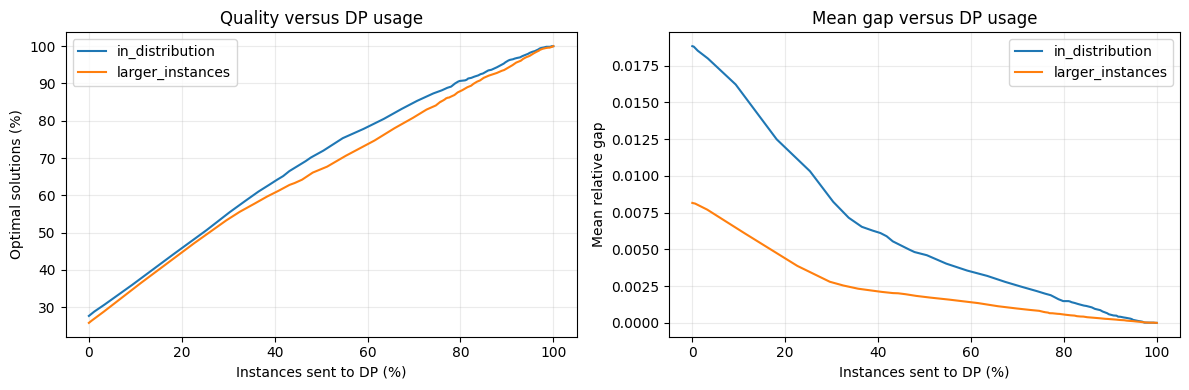

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

for dataset_name, rows in logistic_tradeoff.groupby("dataset"):
    axes[0].plot(
        rows["percentage_sent_to_dp"],
        100 * rows["optimal_solution_rate"],
        label=dataset_name,
    )
    axes[1].plot(
        rows["percentage_sent_to_dp"],
        rows["mean_relative_gap"],
        label=dataset_name,
    )

axes[0].set(
    xlabel="Instances sent to DP (%)",
    ylabel="Optimal solutions (%)",
    title="Quality versus DP usage",
)
axes[1].set(
    xlabel="Instances sent to DP (%)",
    ylabel="Mean relative gap",
    title="Mean gap versus DP usage",
)
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
figure.tight_layout()

## Only now compare a random forest

Logistic regression learns one linear decision boundary after scaling. A random forest can learn nonlinear feature interactions, so it may improve failure detection. It can also overfit the training distribution. We keep the training data and input features identical, use a fixed random state, and compare both models at threshold 0.5 and across the full routing curve.

In [7]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=0,
    n_jobs=-1,
)
random_forest.fit(
    train[list(FEATURE_COLUMNS)], train["failure"].astype(int)
)

model_comparison_rows = []
for model_name, model in {
    "logistic_regression": logistic_model,
    "random_forest": random_forest,
}.items():
    for dataset_name, frame in {
        "in_distribution": in_distribution_test,
        "larger_instances": out_of_distribution_test,
    }.items():
        row = threshold_tradeoff(model, frame, dataset_name)
        row = row.loc[np.isclose(row["threshold"], 0.5)].iloc[0]
        model_comparison_rows.append({
            "model": model_name,
            "dataset": dataset_name,
            "optimal_solution_rate": row["optimal_solution_rate"],
            "mean_relative_gap": row["mean_relative_gap"],
            "maximum_relative_gap": row["maximum_relative_gap"],
            "percentage_sent_to_dp": row["percentage_sent_to_dp"],
            "false_negatives": int(row["false_negatives"]),
        })

model_comparison = pd.DataFrame(model_comparison_rows)
model_comparison.round(4)

,model,dataset,optimal_solution_rate,mean_relative_gap,maximum_relative_gap,percentage_sent_to_dp,false_negatives
0,logistic_regression,in_distribution,0.9367,0.0010,0.0432,86.6667,38
1,logistic_regression,larger_instances,0.8990,0.0005,0.0131,82.8000,101
2,random_forest,in_distribution,0.8883,0.0018,0.0613,77.8333,67
3,random_forest,larger_instances,0.8710,0.0006,0.0222,79.9000,129


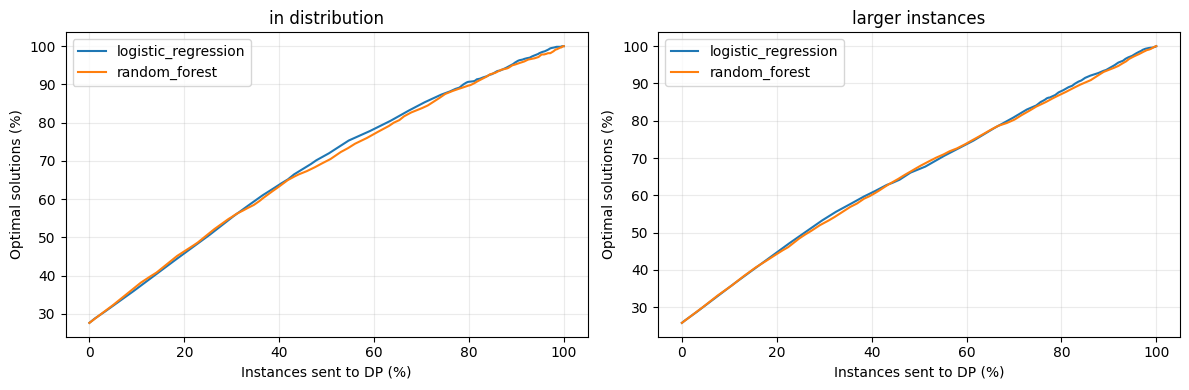

In [8]:
all_tradeoffs = []
for model_name, model in {
    "logistic_regression": logistic_model,
    "random_forest": random_forest,
}.items():
    for dataset_name, frame in {
        "in_distribution": in_distribution_test,
        "larger_instances": out_of_distribution_test,
    }.items():
        rows = threshold_tradeoff(model, frame, dataset_name)
        rows["model"] = model_name
        all_tradeoffs.append(rows)

all_tradeoffs = pd.concat(all_tradeoffs, ignore_index=True)
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

for axis, (dataset_name, rows) in zip(
    axes, all_tradeoffs.groupby("dataset", sort=False)
):
    for model_name, model_rows in rows.groupby("model"):
        axis.plot(
            model_rows["percentage_sent_to_dp"],
            100 * model_rows["optimal_solution_rate"],
            label=model_name,
        )
    axis.set(
        xlabel="Instances sent to DP (%)",
        ylabel="Optimal solutions (%)",
        title=dataset_name.replace("_", " "),
    )
    axis.legend()
    axis.grid(alpha=0.25)
figure.tight_layout()

## Interpretation and learning checkpoint

The size shift matters. At threshold 0.5, logistic regression's failure recall falls from 91.2% on the held-out 20-item set to 86.4% on the 40-item set. Consequently, the hybrid optimal-solution rate falls from 93.67% to 89.90%, even though it sends a similar share of instances to DP (86.67% versus 82.80%). The lower OOD mean gap does not contradict this decline: failures are more frequent, but the missed greedy solutions tend to lose a smaller fraction of the optimum.

The threshold curve makes the cost explicit. On the larger instances, lowering the logistic threshold from 0.5 to 0.25 raises the optimal-solution rate from 89.90% to 99.80%, but DP usage rises from 82.80% to 99.70%. A threshold is therefore not inherently good; it encodes the acceptable cost-versus-quality tradeoff.

The random forest does not dominate the linear baseline. At threshold 0.5 it uses less DP in-distribution, but it also returns fewer optimal solutions (88.83% versus 93.67%). On larger instances it again has lower optimality (87.10% versus 89.90%) and more false negatives. Compare the full curves—not only equal numeric thresholds—when choosing between models, because their probabilities are calibrated differently.

The central lesson is that a strong in-distribution score is not enough to establish a reliable selector. The routing policy must be evaluated under plausible shifts, and its threshold must be chosen from the downstream quality-versus-computation curve.